# EDA — Palmer Penguins Dataset
**TC2004B · Análisis Exploratorio de Datos**

> **Fuente:** Gorman KB, Williams TD, Fraser WR (2014). *Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins.* PLoS ONE.  
> Disponible en: `seaborn.load_dataset('penguins')` / [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/)

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
PALETTE = {'Adelie': '#E07B54', 'Chinstrap': '#6A7FC1', 'Gentoo': '#4BAE8A'}

# Load
df = sns.load_dataset('penguins')
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
df.head()

Filas: 344  |  Columnas: 7


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## 1 · Contexto del Dataset

El **Palmer Penguins Dataset** fue recolectado entre 2007 y 2009 en el **Archipiélago Palmer**, Antártida. Contiene mediciones morfológicas de **344 pingüinos** de tres especies distintas.

### Variables clave

| Variable | Tipo | Descripción |
|---|---|---|
| `species` | Categórica | Especie: *Adelie*, *Chinstrap*, *Gentoo* |
| `island` | Categórica | Isla: *Biscoe*, *Dream*, *Torgersen* |
| `bill_length_mm` | Numérica | Longitud del pico (mm) |
| `bill_depth_mm` | Numérica | Profundidad del pico (mm) |
| `flipper_length_mm` | Numérica | Longitud de la aleta (mm) |
| `body_mass_g` | Numérica | Masa corporal (g) |
| `sex` | Categórica | Sexo: *Male*, *Female* |

**¿Por qué es interesante?** Es el conjunto de datos más usado para enseñar clasificación y EDA como alternativa moderna al dataset Iris — tiene variables biológicas reales con ruido, valores faltantes y patrones de dimorfismo sexual.

In [2]:
# Mapa de islas y especies
print('=== DISTRIBUCIÓN ESPECIE × ISLA ===')
print(pd.crosstab(df['species'], df['island'], margins=True))

=== DISTRIBUCIÓN ESPECIE × ISLA ===
island     Biscoe  Dream  Torgersen  All
species                                 
Adelie         44     56         52  152
Chinstrap       0     68          0   68
Gentoo        124      0          0  124
All           168    124         52  344


---
## 2 · Calidad de Datos

In [3]:
# ── 2.1 Valores faltantes ──────────────────────────────────────────────────
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_missing', ascending=False)
missing = missing[missing['n_missing'] > 0]
print('=== VALORES FALTANTES ===')
print(missing)

# ── 2.2 Duplicados ────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'\nDuplicados exactos: {n_dup}')

# ── 2.3 Tipos de datos ────────────────────────────────────────────────────
print('\n=== TIPOS DE DATOS ===')
print(df.dtypes)

=== VALORES FALTANTES ===
                   n_missing  pct_missing
sex                       11         3.20
bill_length_mm             2         0.58
bill_depth_mm              2         0.58
flipper_length_mm          2         0.58
body_mass_g                2         0.58

Duplicados exactos: 0

=== TIPOS DE DATOS ===
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


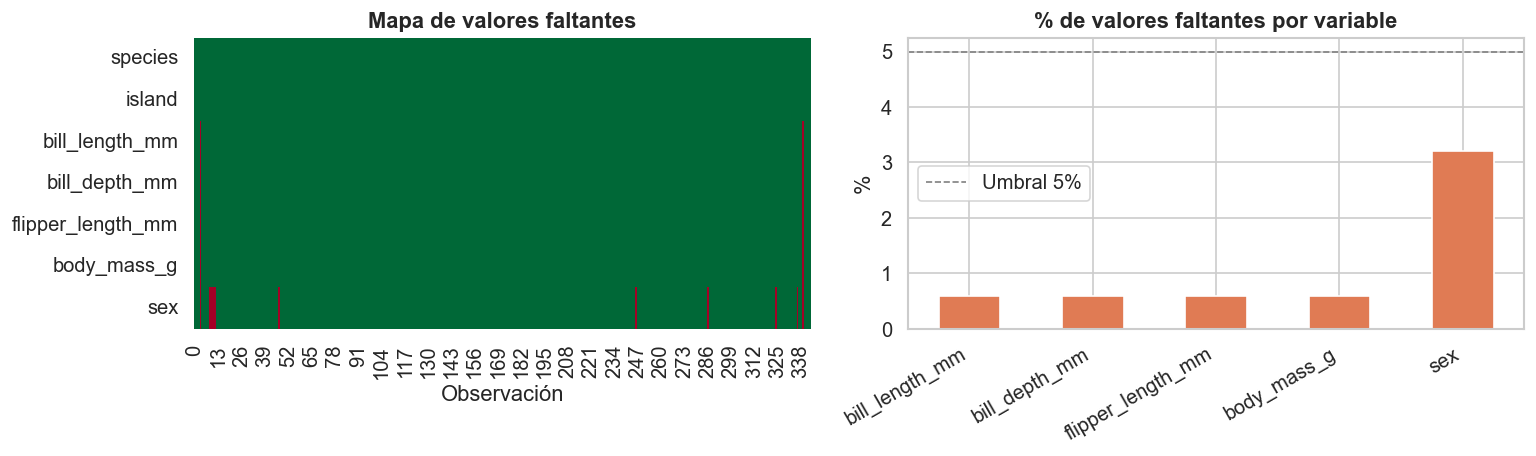

In [4]:
# ── 2.4 Mapa de calor de nulos ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap de nulos
sns.heatmap(
    df.isnull().T,
    ax=axes[0], cbar=False,
    cmap='RdYlGn_r', yticklabels=True
)
axes[0].set_title('Mapa de valores faltantes', fontweight='bold')
axes[0].set_xlabel('Observación')

# Bar chart % faltantes
cols_miss = df.columns[df.isnull().any()]
pct = (df[cols_miss].isnull().sum() / len(df) * 100)
pct.plot(kind='bar', ax=axes[1], color='#E07B54', edgecolor='white')
axes[1].set_title('% de valores faltantes por variable', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(5, ls='--', color='gray', lw=1, label='Umbral 5%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/generated/q1_missing.png', bbox_inches='tight')
plt.show()

In [5]:
# ── 2.5 Revisión de rangos y outliers con IQR ─────────────────────────────
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

def iqr_outliers(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lo) | (series > hi)).sum()
    return pd.Series({'min': series.min(), 'max': series.max(),
                      'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                      'lim_inf': lo, 'lim_sup': hi, 'n_outliers': n_out})

ranges = df[num_cols].apply(iqr_outliers).T
print('=== RANGOS Y OUTLIERS (IQR × 1.5) ===')
print(ranges.round(2))

=== RANGOS Y OUTLIERS (IQR × 1.5) ===
                      min     max       Q1      Q3      IQR  lim_inf  lim_sup  \
bill_length_mm       32.1    59.6    39.22    48.5     9.27    25.31    62.41   
bill_depth_mm        13.1    21.5    15.60    18.7     3.10    10.95    23.35   
flipper_length_mm   172.0   231.0   190.00   213.0    23.00   155.50   247.50   
body_mass_g        2700.0  6300.0  3550.00  4750.0  1200.00  1750.00  6550.00   

                   n_outliers  
bill_length_mm            0.0  
bill_depth_mm             0.0  
flipper_length_mm         0.0  
body_mass_g               0.0  


### Decisiones de calidad de datos

| Problema | Cantidad | Acción recomendada |
|---|---|---|
| Nulos en medidas morfológicas | 2 filas (0.6 %) | **Eliminar** — son pocas filas y no hay información útil |
| Nulos en `sex` | 11 filas (3.2 %) | **Imputar con moda por especie** o marcar como `Unknown` |
| Duplicados exactos | 0 | No se requiere acción |
| Outliers IQR | Ninguno crítico | Conservar — variabilidad biológica real |

> **Nota:** Con <5% de nulos se puede optar por eliminación listwise sin sesgo significativo.

In [6]:
# Aplicar limpieza: eliminar filas sin medidas morfológicas, imputar sex
df_clean = df.dropna(subset=num_cols).copy()
df_clean['sex'] = df_clean.groupby('species')['sex'].transform(
    lambda x: x.fillna(x.mode()[0])
)
print(f'Filas antes: {len(df)}  →  Filas después: {len(df_clean)}')
print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')

Filas antes: 344  →  Filas después: 342
Nulos restantes: 0


---
## 3 · Métricas Básicas

In [7]:
# ── 3.1 Estadística descriptiva completa ──────────────────────────────────
desc = df_clean[num_cols].describe().T
desc['skewness'] = df_clean[num_cols].skew().round(3)
desc['kurtosis'] = df_clean[num_cols].kurt().round(3)
desc['cv_%'] = (desc['std'] / desc['mean'] * 100).round(2)
print('=== ESTADÍSTICA DESCRIPTIVA ===')
desc.round(2)

=== ESTADÍSTICA DESCRIPTIVA ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%
bill_length_mm,342.0,43.92,5.46,32.1,39.22,44.45,48.5,59.6,0.05,-0.88,12.43
bill_depth_mm,342.0,17.15,1.97,13.1,15.60,17.30,18.7,21.5,-0.14,-0.91,11.51
flipper_length_mm,342.0,200.92,14.06,172.0,190.00,197.00,213.0,231.0,0.35,-0.98,7.00
body_mass_g,342.0,4201.75,801.95,2700.0,3550.00,4050.00,4750.0,6300.0,0.47,-0.72,19.09


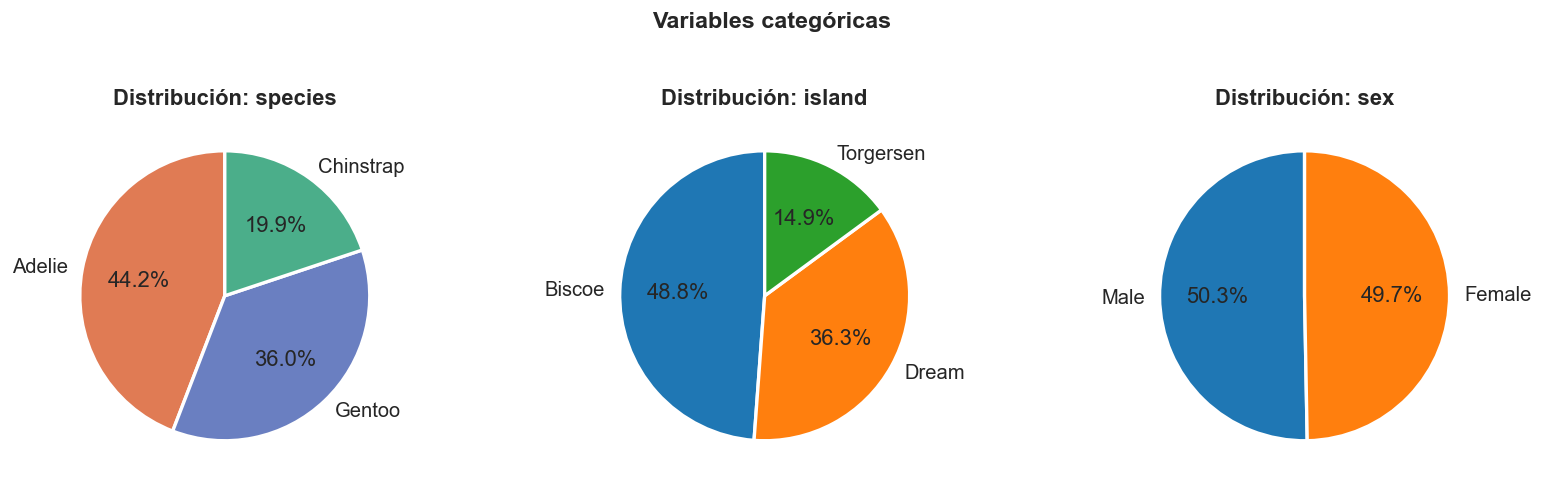

In [8]:
# ── 3.2 Conteos categóricos ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['species', 'island', 'sex']):
    counts = df_clean[col].value_counts()
    colors = list(PALETTE.values())[:len(counts)] if col == 'species' else sns.color_palette('tab10', len(counts))
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'Distribución: {col}', fontweight='bold')

plt.suptitle('Variables categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/generated/q2_categoricas.png', bbox_inches='tight')
plt.show()

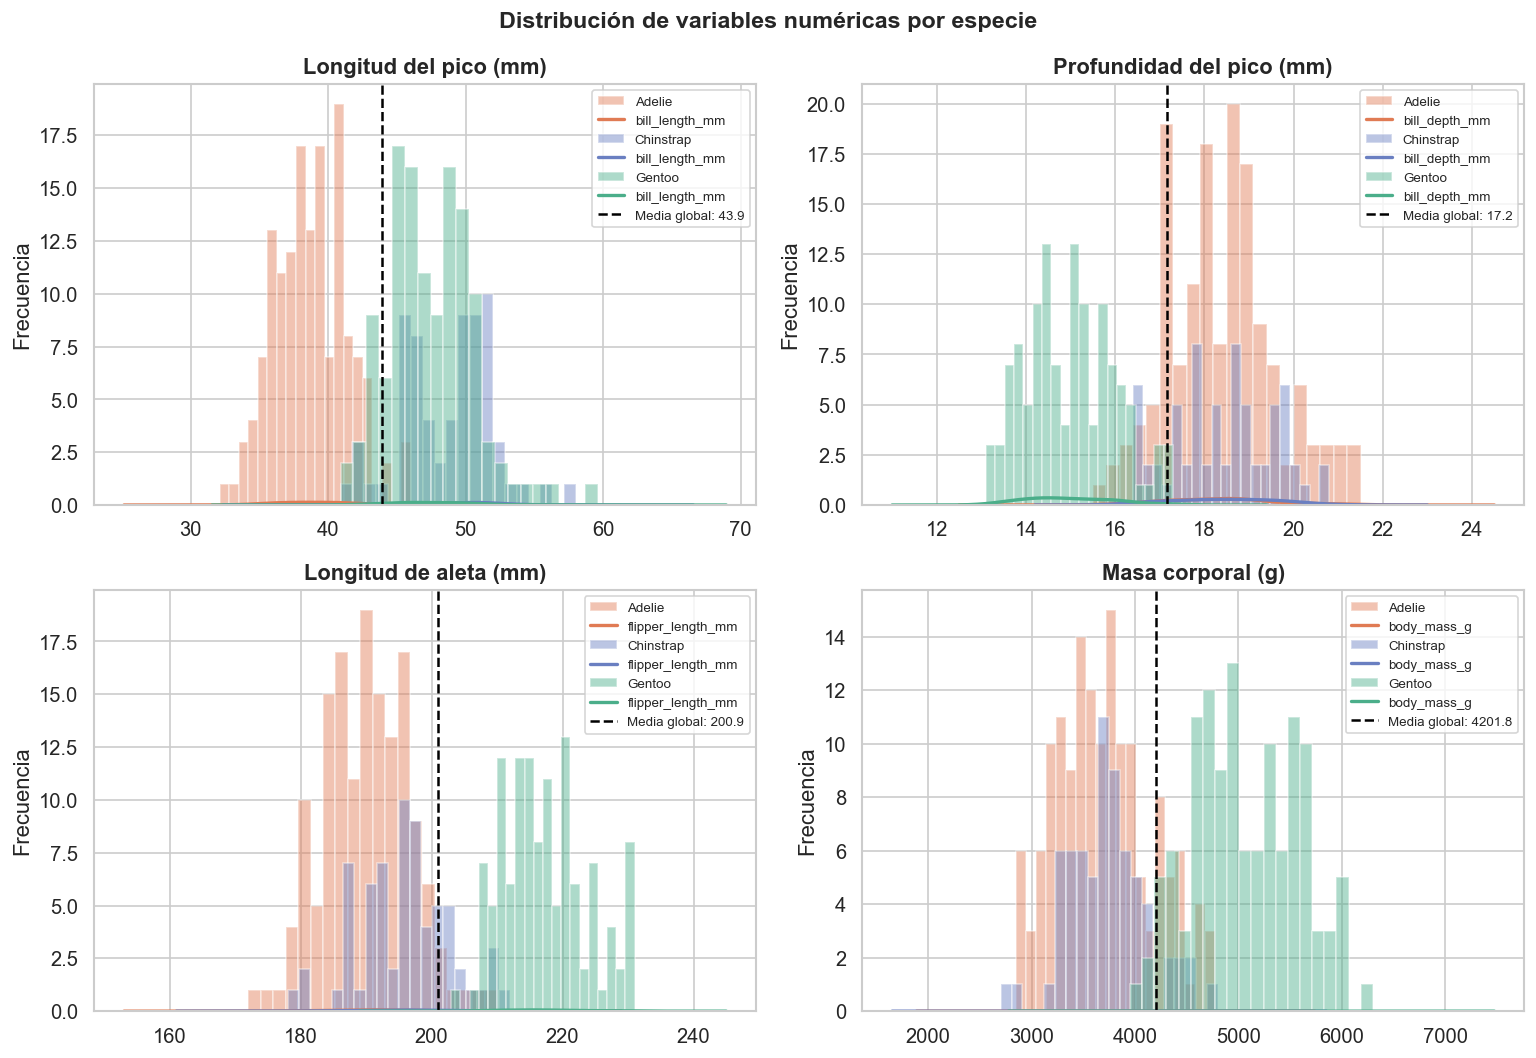

In [9]:
# ── 3.3 Histogramas + KDE por variable numérica ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
labels = {
    'bill_length_mm':    'Longitud del pico (mm)',
    'bill_depth_mm':     'Profundidad del pico (mm)',
    'flipper_length_mm': 'Longitud de aleta (mm)',
    'body_mass_g':       'Masa corporal (g)'
}

for ax, col in zip(axes.flat, num_cols):
    for sp, grp in df_clean.groupby('species'):
        grp[col].plot(kind='hist', ax=ax, alpha=0.45, bins=20,
                      color=PALETTE[sp], label=sp)
        grp[col].plot(kind='kde', ax=ax, color=PALETTE[sp], lw=2)

    ax.set_title(labels[col], fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend(title='Especie')

    # Añadir media global
    mu = df_clean[col].mean()
    ax.axvline(mu, color='black', ls='--', lw=1.5, label=f'Media global: {mu:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por especie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/generated/q3_histogramas.png', bbox_inches='tight')
plt.show()

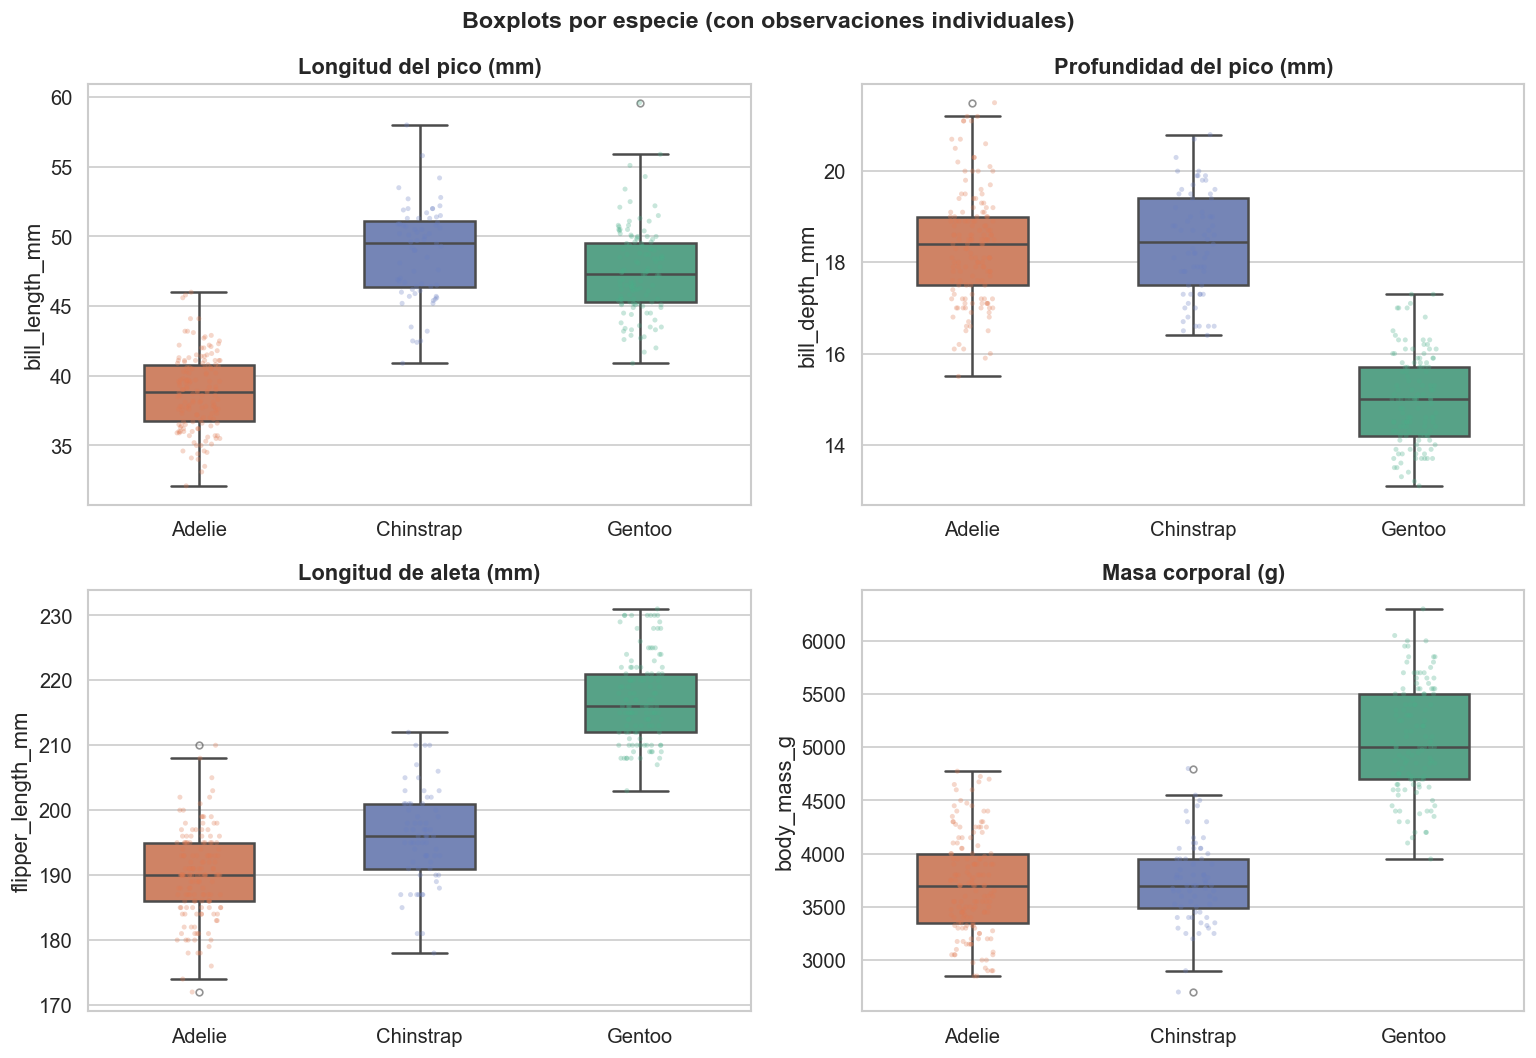

In [10]:
# ── 3.4 Boxplots: métrica × especie ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(
        data=df_clean, x='species', y=col,
        palette=PALETTE, ax=ax,
        order=['Adelie', 'Chinstrap', 'Gentoo'],
        width=0.5, linewidth=1.5,
        flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.6}
    )
    sns.stripplot(
        data=df_clean, x='species', y=col,
        palette=PALETTE, ax=ax,
        order=['Adelie', 'Chinstrap', 'Gentoo'],
        alpha=0.3, size=3, jitter=True
    )
    ax.set_title(labels[col], fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Boxplots por especie (con observaciones individuales)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/generated/q4_boxplots.png', bbox_inches='tight')
plt.show()

---
## 4 · Hipótesis de Exploración

A partir del contexto del dataset y las métricas básicas, planteamos las siguientes hipótesis:

| # | Hipótesis | Variable(s) | Tipo |
|---|---|---|---|
| H1 | **Las tres especies son morfológicamente separables** por sus medidas de pico y aleta | bill_*, flipper_length | Separabilidad |
| H2 | **Gentoo es la especie más grande** en masa corporal y aleta | body_mass_g, flipper_length_mm | Comparación de grupos |
| H3 | **Existe dimorfismo sexual**: los machos son más pesados que las hembras dentro de cada especie | body_mass_g, sex, species | Dimorfismo |
| H4 | **Longitud y profundidad de pico están correlacionadas negativamente** a nivel global (paradoja de Simpson) | bill_length, bill_depth | Correlación |
| H5 | **La isla determina parcialmente la especie** presente (distribución geográfica) | island, species | Distribución |

> Las siguientes celdas validan cada hipótesis visualmente y con métricas.

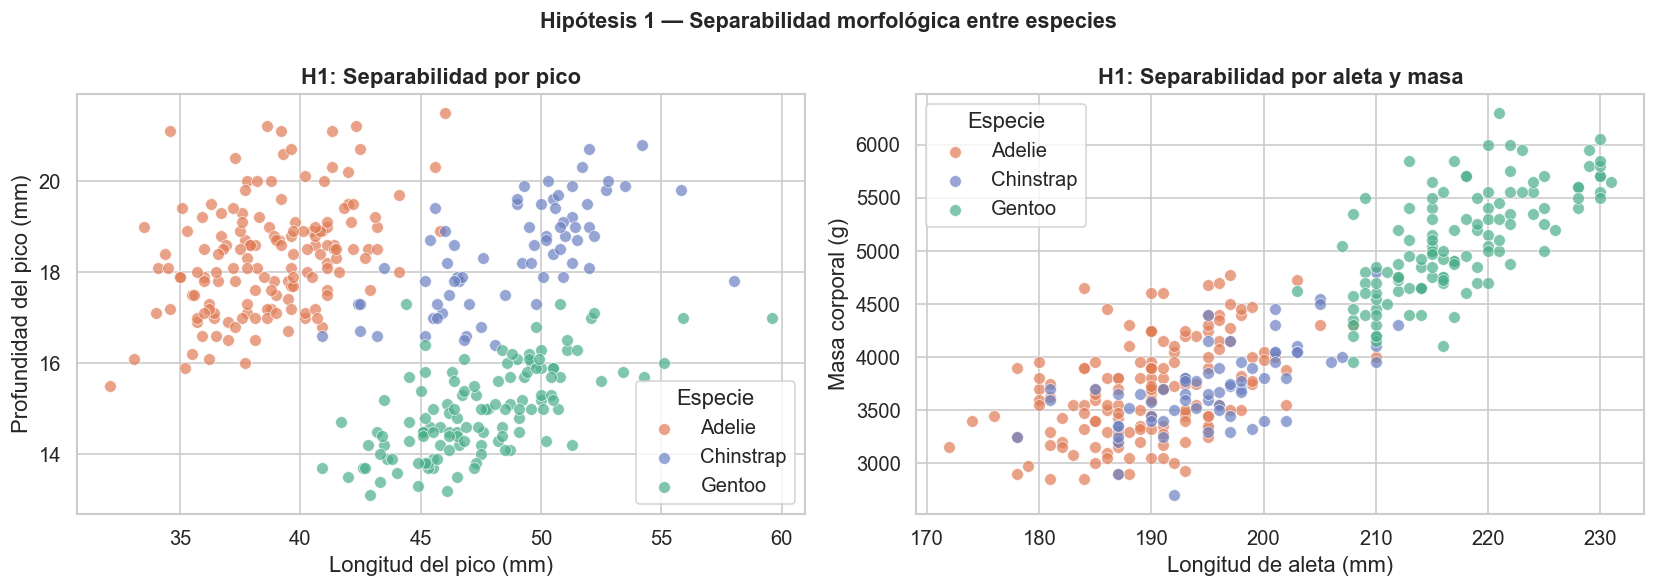

In [11]:
# ── H1 · Separabilidad por especie — Scatter bill_length vs bill_depth ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1
for sp, grp in df_clean.groupby('species'):
    axes[0].scatter(grp['bill_length_mm'], grp['bill_depth_mm'],
                    color=PALETTE[sp], label=sp, alpha=0.7, s=50, edgecolors='white', lw=0.5)
axes[0].set_xlabel('Longitud del pico (mm)')
axes[0].set_ylabel('Profundidad del pico (mm)')
axes[0].set_title('H1: Separabilidad por pico', fontweight='bold')
axes[0].legend(title='Especie')

# Scatter 2: flipper vs body_mass
for sp, grp in df_clean.groupby('species'):
    axes[1].scatter(grp['flipper_length_mm'], grp['body_mass_g'],
                    color=PALETTE[sp], label=sp, alpha=0.7, s=50, edgecolors='white', lw=0.5)
axes[1].set_xlabel('Longitud de aleta (mm)')
axes[1].set_ylabel('Masa corporal (g)')
axes[1].set_title('H1: Separabilidad por aleta y masa', fontweight='bold')
axes[1].legend(title='Especie')

plt.suptitle('Hipótesis 1 — Separabilidad morfológica entre especies', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/generated/h1_separabilidad.png', bbox_inches='tight')
plt.show()

=== MEDIAS POR ESPECIE ===
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               38.8           18.3              190.0       3700.7
Chinstrap            48.8           18.4              195.8       3733.1
Gentoo               47.5           15.0              217.2       5076.0


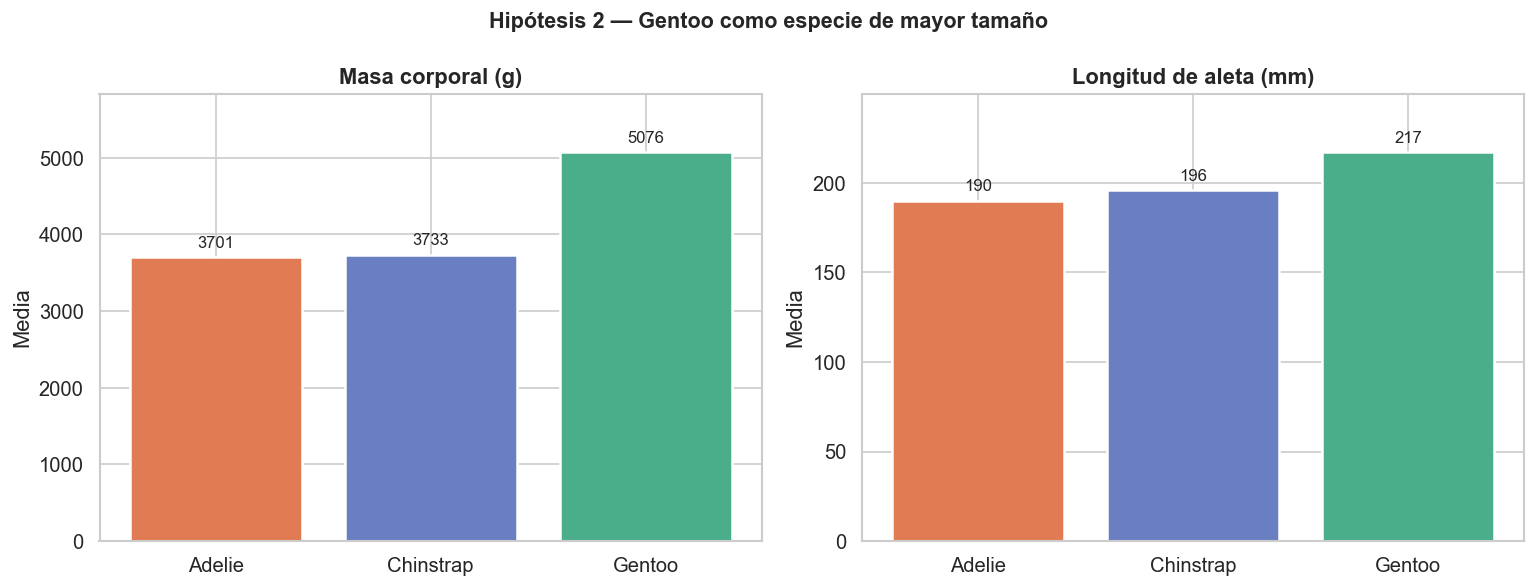

In [12]:
# ── H2 · Gentoo es la especie más grande ─────────────────────────────────
medias = df_clean.groupby('species')[num_cols].mean().round(1)
print('=== MEDIAS POR ESPECIE ===')
print(medias)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['body_mass_g', 'flipper_length_mm']):
    bars = ax.bar(
        medias.index,
        medias[col],
        color=[PALETTE[s] for s in medias.index],
        edgecolor='white', linewidth=1.5
    )
    ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10)
    ax.set_title(labels[col], fontweight='bold')
    ax.set_ylabel('Media')
    ax.set_ylim(0, medias[col].max() * 1.15)

plt.suptitle('Hipótesis 2 — Gentoo como especie de mayor tamaño', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/generated/h2_gentoo.png', bbox_inches='tight')
plt.show()

=== MASA CORPORAL MEDIA: sexo × especie ===
                    mean    std
species   sex                  
Adelie    Female  3379.8  285.4
          Male    4043.5  346.8
Chinstrap Female  3527.2  285.3
          Male    3939.0  362.1
Gentoo    Female  4679.7  281.6
          Male    5429.6  380.2


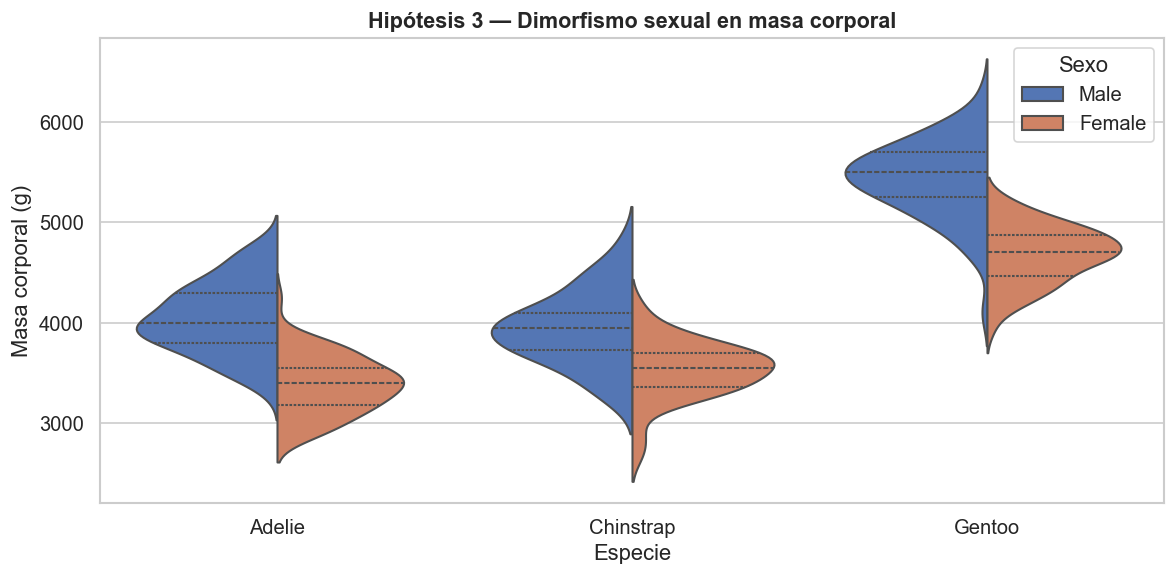

In [13]:
# ── H3 · Dimorfismo sexual ────────────────────────────────────────────────
print('=== MASA CORPORAL MEDIA: sexo × especie ===')
dimorf = df_clean.groupby(['species', 'sex'])['body_mass_g'].agg(['mean', 'std']).round(1)
print(dimorf)

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_clean, x='species', y='body_mass_g',
    hue='sex', split=True,
    palette={'Male': '#4472C4', 'Female': '#E07B54'},
    order=['Adelie', 'Chinstrap', 'Gentoo'],
    inner='quartile', ax=ax
)
ax.set_title('Hipótesis 3 — Dimorfismo sexual en masa corporal', fontweight='bold', fontsize=13)
ax.set_xlabel('Especie')
ax.set_ylabel('Masa corporal (g)')
ax.legend(title='Sexo')

plt.tight_layout()
plt.savefig('../figures/generated/h3_dimorfismo.png', bbox_inches='tight')
plt.show()

Correlación GLOBAL  bill_length vs bill_depth: r = -0.235  (p = 0.0000)

  Adelie: r = 0.391  (p = 0.0000)
  Chinstrap: r = 0.654  (p = 0.0000)
  Gentoo: r = 0.643  (p = 0.0000)


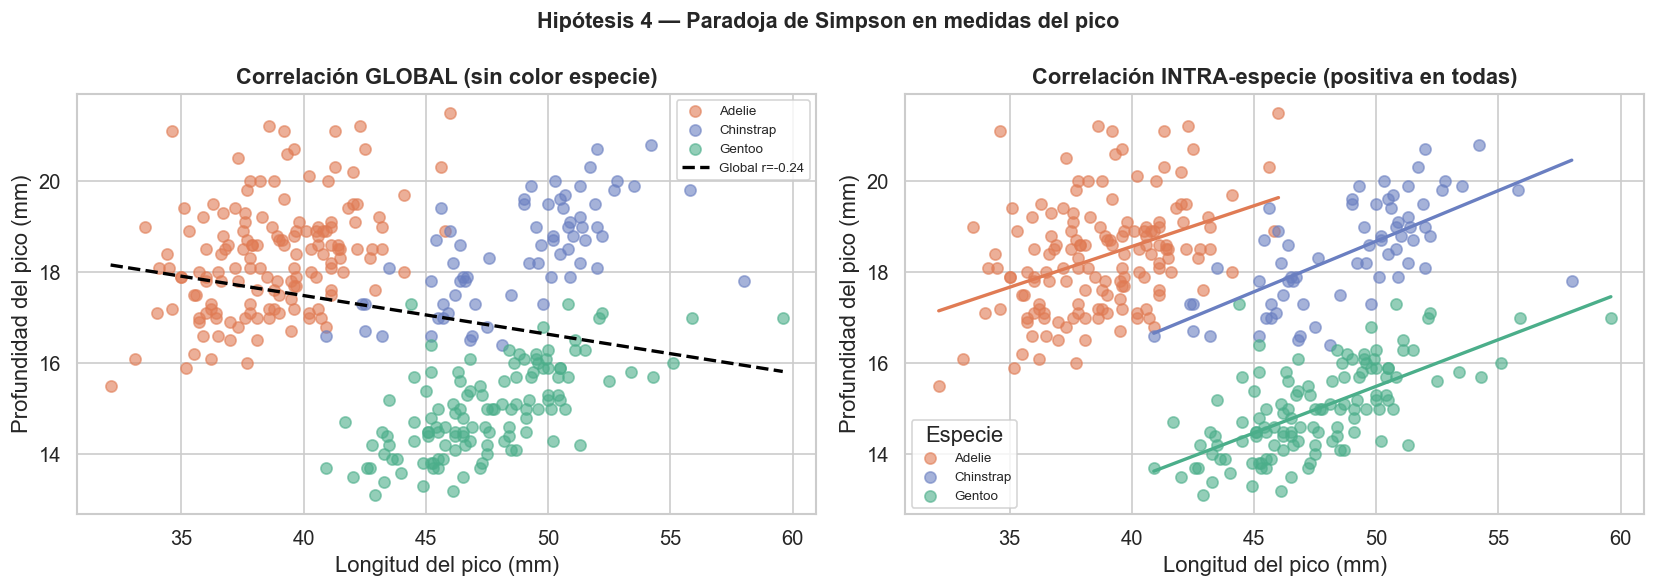

In [14]:
# ── H4 · Paradoja de Simpson en correlación de pico ──────────────────────
r_global, p_global = stats.pearsonr(
    df_clean['bill_length_mm'].dropna(),
    df_clean['bill_depth_mm'].dropna()
)

print(f'Correlación GLOBAL  bill_length vs bill_depth: r = {r_global:.3f}  (p = {p_global:.4f})')
print()
for sp, grp in df_clean.groupby('species'):
    r, p = stats.pearsonr(grp['bill_length_mm'], grp['bill_depth_mm'])
    print(f'  {sp}: r = {r:.3f}  (p = {p:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot global
for sp, grp in df_clean.groupby('species'):
    axes[0].scatter(grp['bill_length_mm'], grp['bill_depth_mm'],
                    color=PALETTE[sp], alpha=0.6, s=45, label=sp)
m, b = np.polyfit(df_clean['bill_length_mm'], df_clean['bill_depth_mm'], 1)
x_line = np.linspace(df_clean['bill_length_mm'].min(), df_clean['bill_length_mm'].max(), 100)
axes[0].plot(x_line, m * x_line + b, 'k--', lw=2, label=f'Global r={r_global:.2f}')
axes[0].set_title('Correlación GLOBAL (sin color especie)', fontweight='bold')
axes[0].set_xlabel('Longitud del pico (mm)')
axes[0].set_ylabel('Profundidad del pico (mm)')
axes[0].legend(fontsize=8)

# Plot por especie
for sp, grp in df_clean.groupby('species'):
    axes[1].scatter(grp['bill_length_mm'], grp['bill_depth_mm'],
                    color=PALETTE[sp], alpha=0.6, s=45, label=sp)
    m2, b2 = np.polyfit(grp['bill_length_mm'], grp['bill_depth_mm'], 1)
    x2 = np.linspace(grp['bill_length_mm'].min(), grp['bill_length_mm'].max(), 100)
    axes[1].plot(x2, m2 * x2 + b2, color=PALETTE[sp], lw=2)
axes[1].set_title('Correlación INTRA-especie (positiva en todas)', fontweight='bold')
axes[1].set_xlabel('Longitud del pico (mm)')
axes[1].set_ylabel('Profundidad del pico (mm)')
axes[1].legend(title='Especie', fontsize=8)

plt.suptitle('Hipótesis 4 — Paradoja de Simpson en medidas del pico', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/generated/h4_simpson.png', bbox_inches='tight')
plt.show()

=== CONTEO ESPECIE × ISLA ===
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     123
Dream          56         68       0
Torgersen      51          0       0


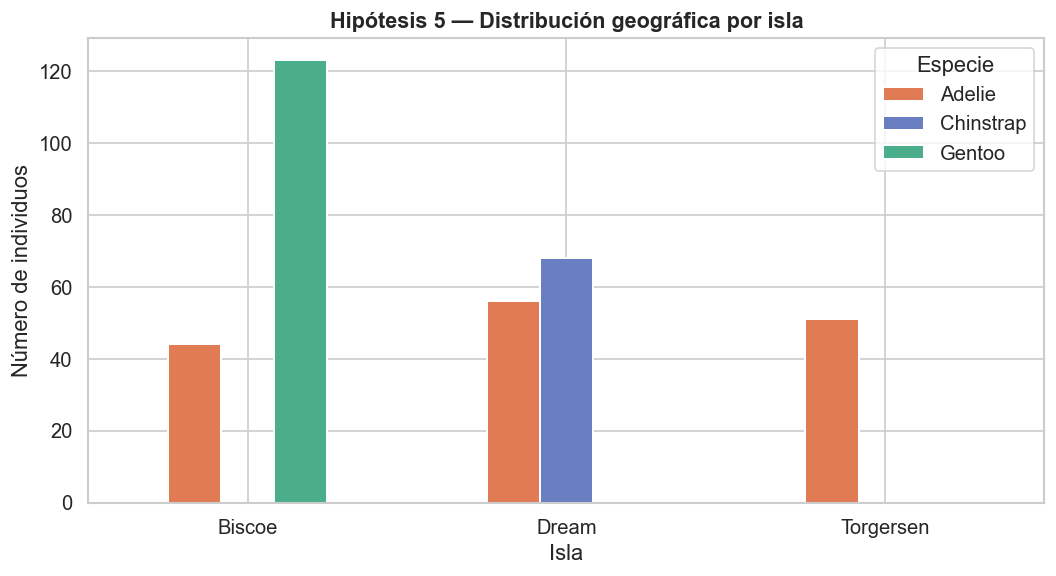

In [15]:
# ── H5 · Distribución geográfica especie × isla ───────────────────────────
ct = pd.crosstab(df_clean['island'], df_clean['species'])
print('=== CONTEO ESPECIE × ISLA ===')
print(ct)

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind='bar', ax=ax, color=[PALETTE[c] for c in ct.columns],
        edgecolor='white', linewidth=1.2)
ax.set_title('Hipótesis 5 — Distribución geográfica por isla', fontweight='bold', fontsize=13)
ax.set_xlabel('Isla')
ax.set_ylabel('Número de individuos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Especie')

plt.tight_layout()
plt.savefig('../figures/generated/h5_geografia.png', bbox_inches='tight')
plt.show()

---
## 5 · Información Adicional Relevante

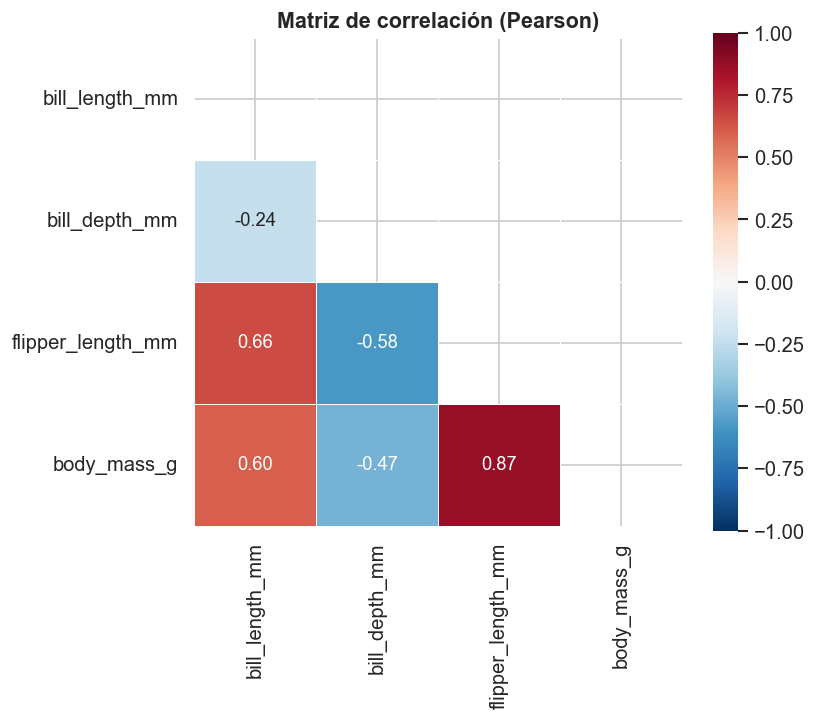

In [16]:
# ── 5.1 Matriz de correlación ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    mask=mask, ax=ax, square=True,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11}
)
ax.set_title('Matriz de correlación (Pearson)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/generated/q5_correlacion.png', bbox_inches='tight')
plt.show()

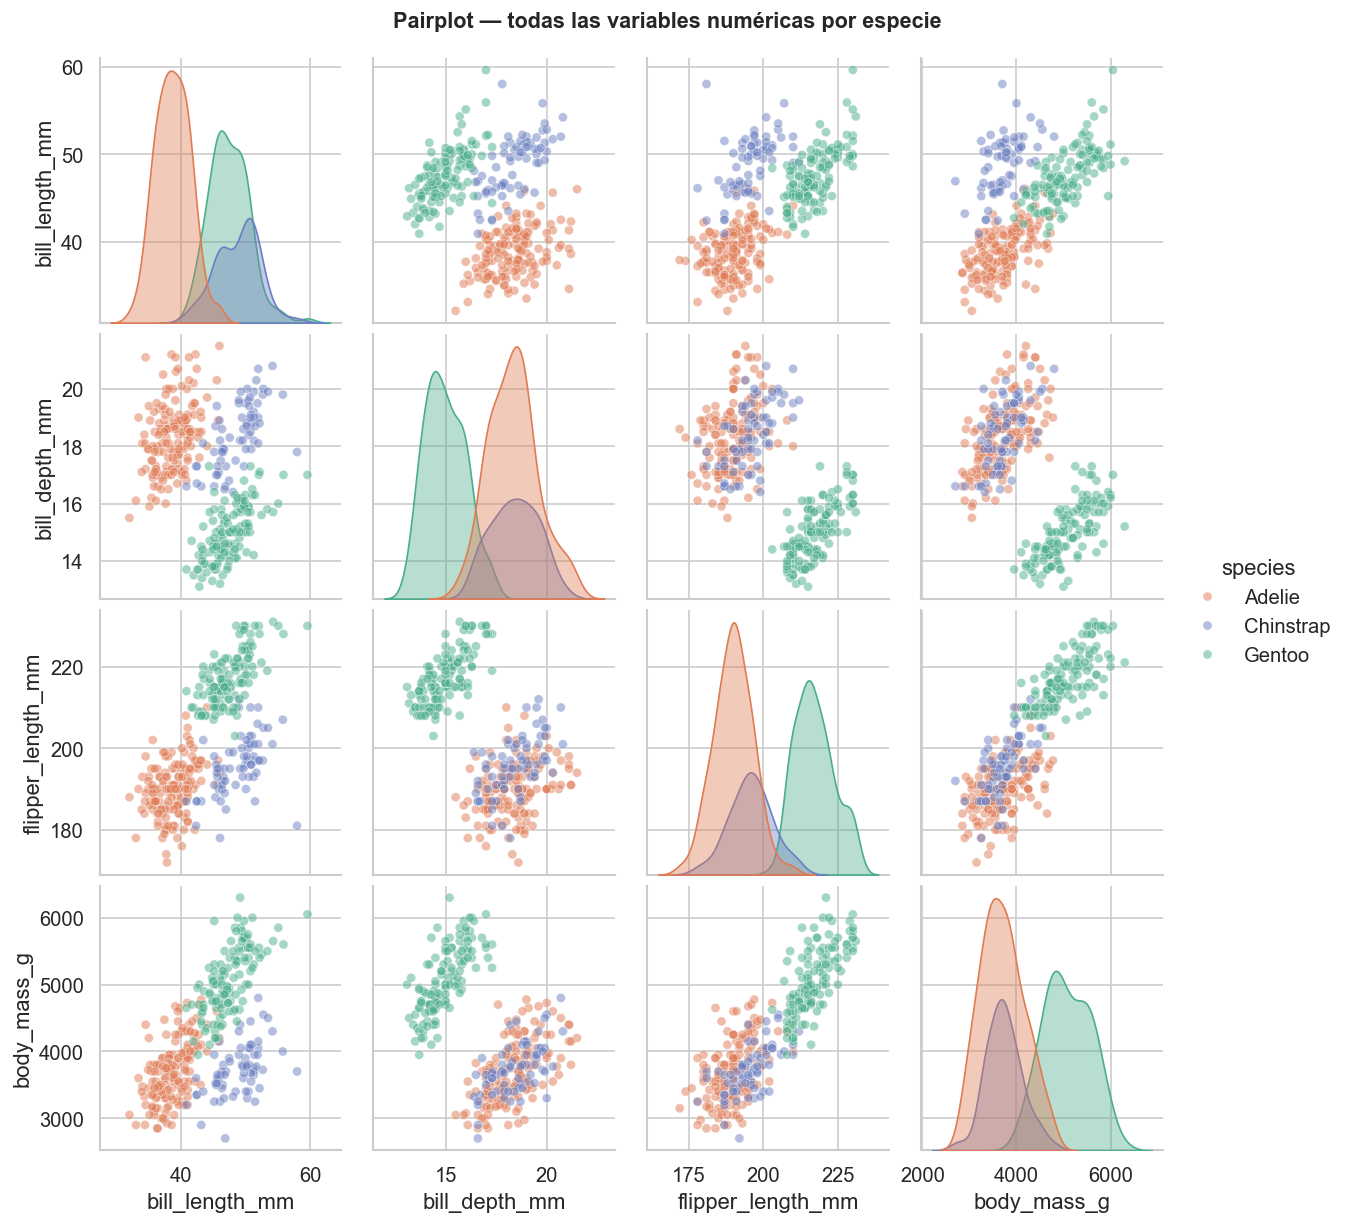

In [17]:
# ── 5.2 Pairplot completo ─────────────────────────────────────────────────
g = sns.pairplot(
    df_clean, hue='species', palette=PALETTE,
    vars=num_cols, diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30},
    diag_kws={'fill': True, 'alpha': 0.4}
)
g.fig.suptitle('Pairplot — todas las variables numéricas por especie',
               y=1.02, fontweight='bold', fontsize=13)
g.fig.savefig('../figures/generated/q6_pairplot.png', bbox_inches='tight')
plt.show()

In [18]:
# ── 5.3 Pruebas estadísticas rápidas (ANOVA) ──────────────────────────────
from scipy.stats import f_oneway

print('=== ANOVA DE UN FACTOR: especie vs cada variable numérica ===')
for col in num_cols:
    grupos = [grp[col].dropna().values for _, grp in df_clean.groupby('species')]
    F, p = f_oneway(*grupos)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {col:<25} F={F:8.2f}  p={p:.2e}  {sig}')

=== ANOVA DE UN FACTOR: especie vs cada variable numérica ===
  bill_length_mm            F=  410.60  p=2.69e-91  ***
  bill_depth_mm             F=  359.79  p=1.51e-84  ***
  flipper_length_mm         F=  594.80  p=1.35e-111  ***
  body_mass_g               F=  343.63  p=2.89e-82  ***


In [19]:
# ── 5.4 Resumen ejecutivo en tabla ────────────────────────────────────────
resumen = df_clean.groupby('species')[num_cols].agg(['mean', 'std']).round(1)
print('=== RESUMEN ESTADÍSTICO POR ESPECIE ===')
resumen

=== RESUMEN ESTADÍSTICO POR ESPECIE ===


bill_length_mm      bill_depth_mm      flipper_length_mm       \
                    mean  std          mean  std              mean  std   
species                                                                   
Adelie              38.8  2.7          18.3  1.2             190.0  6.5   
Chinstrap           48.8  3.3          18.4  1.1             195.8  7.1   
Gentoo              47.5  3.1          15.0  1.0             217.2  6.5   

          body_mass_g         
                 mean    std  
species                       
Adelie         3700.7  458.6  
Chinstrap      3733.1  384.3  
Gentoo         5076.0  504.1

---
## 6 · Conclusiones del EDA

### Calidad de datos
- El dataset es **limpio** con solo 11 nulos en `sex` (3.2%) y 2 filas sin medidas morfológicas.  
- Sin duplicados ni valores fuera de rango biológicamente plausible.

### Hallazgos clave

| Hipótesis | Resultado |
|---|---|
| **H1** — Separabilidad | ✅ Confirmada: las tres especies forman clusters visibles en bill_length vs bill_depth |
| **H2** — Gentoo más grande | ✅ Confirmada: masa media ~5,076 g vs ~3,706 g de Adelie |
| **H3** — Dimorfismo sexual | ✅ Confirmada: machos ~+600 g más pesados que hembras en todas las especies |
| **H4** — Paradoja de Simpson | ✅ Confirmada: correlación global negativa (r = −0.23), positiva intra-especie |
| **H5** — Distribución geográfica | ✅ Confirmada: Adelie en las 3 islas; Gentoo solo en Biscoe; Chinstrap solo en Dream |

### Implicaciones para modelado
1. La variable `species` es **altamente separable** con solo 2-3 features morfológicas → buen candidato para clasificación.
2. **No usar correlación global** entre variables del pico sin controlar por especie (Paradoja de Simpson).
3. `island` es un **proxy fuerte** de especie, cuidado con colinealidad en modelos.
4. El **dimorfismo sexual** sugiere incluir `sex` como feature en modelos de predicción de masa.